In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

In [18]:
import xarray as xr
data_hyper = xr.open_dataset('data/paris/paris-before-prs.nc')
wavelength_hyper = data_hyper["cw"].data
wavelength_hyper = np.round(wavelength_hyper).astype(int) 

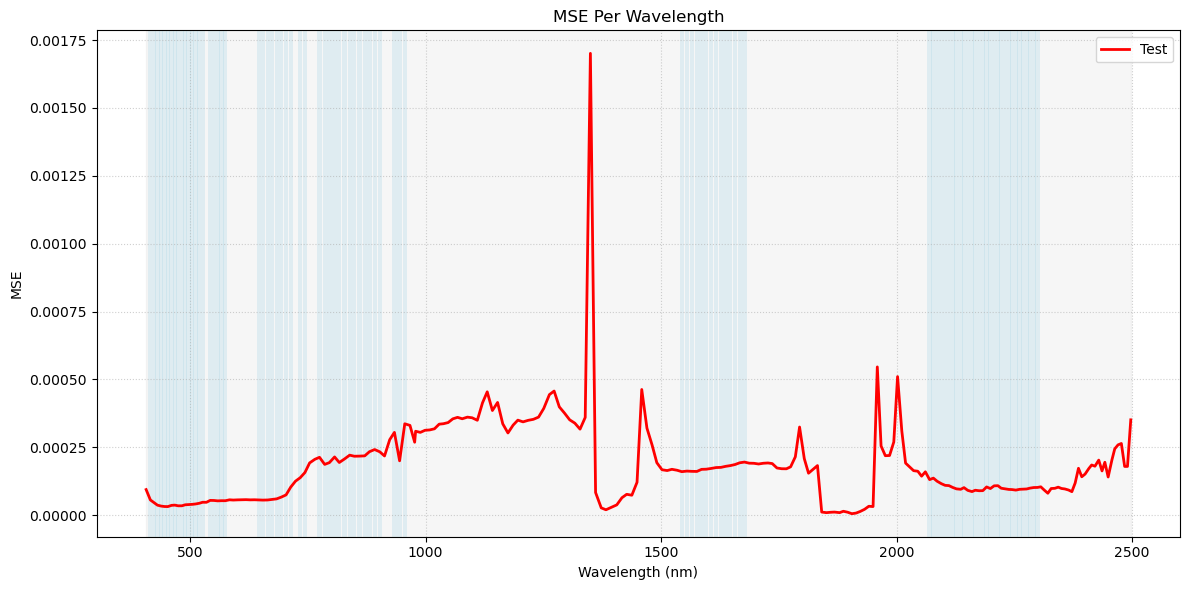

In [15]:
mse_msi_to_hsi = np.load("data/msi_to_hsi_mse_per_channel.npy")

srf_matrix_norm = np.load("data/srf_matrix_norm_s2b.npy") 
included_hsi_chs = np.unique(np.where(srf_matrix_norm != 0)[0])

fig, ax = plt.subplots(figsize=(12,6))

w_min = wavelength_hyper[0]
w_max = wavelength_hyper[-1]
ax.axvspan(w_min, w_max, color='lightgray', alpha=0.2)

half_width = np.median(np.diff(wavelength_hyper)) / 2.0

for ch in included_hsi_chs:
    wl = wavelength_hyper[ch] 
    ax.axvspan(wl - half_width, wl + half_width, color='lightblue', alpha=0.3, lw=0)

ax.plot(wavelength_hyper, mse_msi_to_hsi, label='Test', color='red', linewidth=2)

ax.set_title("MSE Per Wavelength")
ax.set_xlabel("Wavelength (nm)") 
ax.set_ylabel("MSE")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
#plt.savefig(save_path, dpi=300)
plt.show()
plt.close()

In [37]:
max_error_idx = np.argmax(mse_msi_to_hsi)
max_error_wavelength = wavelength_hyper[max_error_idx]

print(f"Maximal error on wavelength : {max_error_wavelength} nm")

Maximal error on wavelength : 1350 nm


In [28]:
true_error = np.load("data/uncertainty_evaluation/final_nafnet/test_true_target_per_channel.npy")
predicted_mean_error   = np.load("data/uncertainty_evaluation/final_nafnet/test_mean_pred_per_channel.npy")
var  =np.load("data/uncertainty_evaluation/final_nafnet/test_var_per_channel.npy")


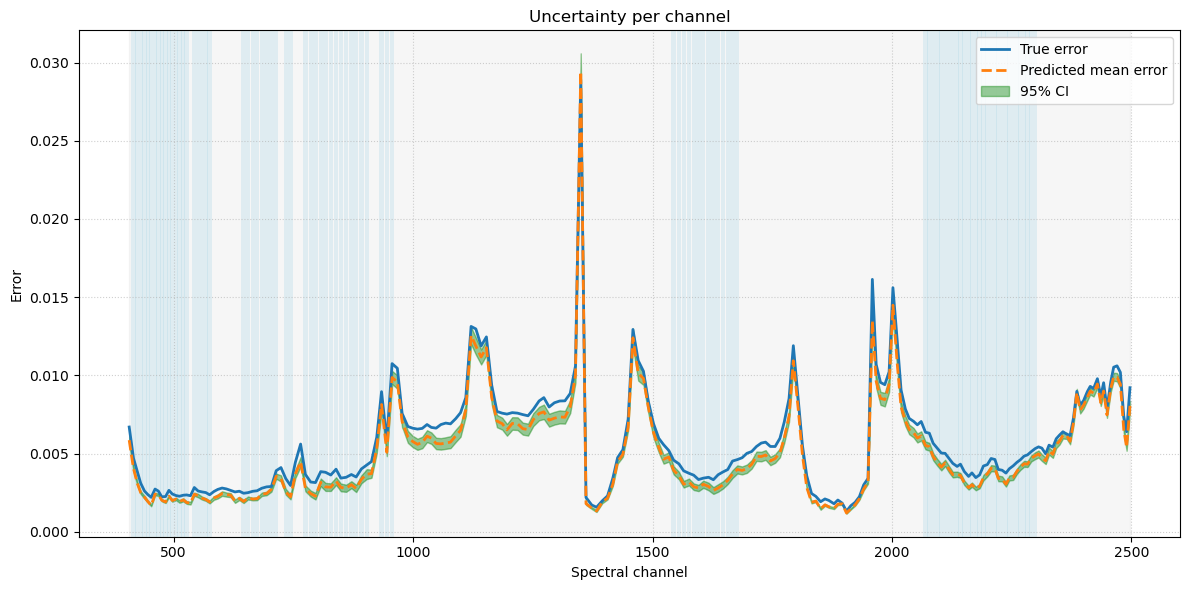

In [34]:
channels = np.arange(len(true_error))

std = np.sqrt(var)
ci = 1.96 * std

lower = np.maximum(0, predicted_mean_error - ci)
upper = predicted_mean_error + ci

plt.figure(figsize=(12, 6))

plt.axvspan(w_min, w_max, color='lightgray', alpha=0.2)
half_width = np.median(np.diff(wavelength_hyper)) / 2.0

for ch in included_hsi_chs:
    wl = wavelength_hyper[ch] 
    plt.axvspan(wl - half_width, wl + half_width, color='lightblue', alpha=0.3, lw=0)


plt.plot(wavelength_hyper, true_error, label='True error', linewidth=2)
plt.plot(wavelength_hyper, predicted_mean_error, '--', label='Predicted mean error', linewidth=2)
plt.fill_between(wavelength_hyper, lower, upper, color='green', alpha=0.4, label='95% CI')

plt.title("Uncertainty per channel")
plt.xlabel("Spectral channel")
plt.ylabel("Error")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [36]:
max_error_idx = np.argmax(true_error)
max_error_wavelength = wavelength_hyper[max_error_idx]

print(f"Maximal error on wavelength : {max_error_wavelength} nm")

Maximal error on wavelength : 1350 nm
